# Регуляризация в классическом машинном обучении: теория и практика

## Введение: переобучение и недообучение моделей

В машинном обучении часто возникает дилемма между слишком сложной моделью, которая запоминает данные (переобучение), и слишком простой моделью, которая не улавливает важные зависимости (недообучение). **Переобучение (overfitting)** происходит, когда модель слишком точно подгоняется под обучающие данные, включая шум и выбросы, в результате чего её качество на новых данных резко падает. **Недообучение (underfitting)**, наоборот, означает, что модель слишком простая и не смогла выучить основные закономерности, поэтому плохо работает как на обучающих, так и на тестовых данных. 
#### Хорошая модель должна находить баланс между этими крайностями – иметь достаточно низкую *смещение* (bias) и *дисперсию* (variance).



Одним из ключевых способов борьбы с переобучением является **регуляризация**. Согласно принципу бритвы Оккама, из всех моделей, хорошо описывающих данные, предпочтительна самая простая. Регуляризация явно или неявно воплощает этот принцип, ограничивая сложность модели, чтобы улучшить ее обобщающую способность.

## Что такое регуляризация?

**Регуляризация** – это совокупность техник, которые добавляют к модели специальные ограничения или штрафы с целью избежать переобучения и улучшить способность модели обобщать закономерности. Проще говоря, в процесс обучения вводится дополнительный **штраф за сложность модели**, чтобы модели было выгоднее оставаться более простой (гладкой), даже если это слегка ухудшит приближение обучающих данных. За счёт этого модель меньше подстраивается под шум и лучше работает на новых данных.

Регуляризацию можно представить как дополнительный член в функции ошибки, который растёт, когда модель становится слишком сложной. В результате оптимизация пытается найти компромисс между минимизацией обычной ошибки на обучении и минимизацией этого штрафа за сложность. С точки зрения *Bias-Variance* разложения, регуляризация увеличивает смещение модели, но существенно снижает дисперсию, что часто приводит к более низкой общей ошибке на тестовых данных (если регуляризация выбрана правильно).

На практике существуют разные виды регуляризационных штрафов. Чаще всего используются две схемы:

* **L2-регуляризация (Ridge)** – штраф за **квадрат веса** каждого параметра (также известна как регуляризация Тихонова). Она старается сделать **все веса как можно меньшими**, но обычно не обнуляет их полностью.
* **L1-регуляризация (Lasso)** – штраф за **абсолютное значение веса** каждого параметра. Этот вид регуляризации может приводить к тому, что некоторые параметры становятся ровно нулевыми, фактически исключая соответствующие признаки из модели. То есть L1-регуляризация одновременно выполняет роль отбора признаков.

Также применяется комбинация этих подходов – **Elastic Net**, сочетающая L1 и L2 штрафы, но для простоты мы сфокусируемся на чистых L1 и L2.

Регуляризацию можно применить к большинству моделей: линейным регрессиям, моделям классификации (логистическая регрессия, SVM), деревьям решений (путём ограничения их глубины или пост-обрезки), нейронным сетям (dropout, L2-нормы и др.), и т.д. Далее мы рассмотрим, как это делается на практике для нескольких основных алгоритмов **классического машинного обучения**, и как регуляризация помогает улучшить качество моделей.

## Регуляризация в линейной регрессии: Ridge и Lasso

Рассмотрим сначала **линейную регрессию** – модель, предсказывающую числовой признак по линейной комбинации входных признаков. Линейная модель сама по себе относительно простая, но она может переобучаться в двух сценариях: (1) когда признаков очень много (особенно если число признаков сравнимо или больше числа объектов), и (2) когда между признаками есть сильная корреляция (мультиколлинеарность). В таких случаях решение задачи МНК (метода наименьших квадратов) может давать большие по модулю коэффициенты, пытаясь подогнать данные, что ведёт к высокой дисперсии модели на новых данных.

**Ridge-регрессия (L2).** Чтобы снизить риск переобучения, в **Ridge-регрессии** к стандартной функции потерь (сумме квадратов ошибок) добавляют штраф, пропорциональный сумме квадратов весов модели. Гиперпараметр \$\lambda\$ (лямбда) контролирует силу этого штрафа. Математически критерий выглядит как:

$L_{ridge} = \sum_{i}(y_i - \hat{y_i})^2 + \lambda \sum_{j} w_j^2,$

где \$w\_j\$ – коэффициенты (веса) при признаках. При \$\lambda > 0\$ модель будет стараться минимизировать не только ошибку, но и сами веса. Это приводит к тому, что веса **“усредняются”**: модель не позволяет каким-то одному или нескольким признакам иметь слишком большое влияние. Ridge-регрессия особенно полезна, когда признаки коррелированы – она распределяет вес между такими признаками и тем самым уменьшает эффект мультиколлинеарности. В результате модель становится более устойчивой: небольшие изменения в данных меньше влияют на прогнозы.

**Lasso-регрессия (L1).** В **Lasso-регрессии** добавляется штраф, пропорциональный сумме модулей весов:

$L_{lasso} = \sum_{i}(y_i - \hat{y_i})^2 + \lambda \sum_{j} |w_j|.$

Из-за особых свойств L1-нормы решение такой оптимизационной задачи приводит к тому, что при достаточной величине \$\lambda\$ некоторые веса могут становиться точно нулевыми. Геометрически L1-норма задаёт “ромбовидные” ограничения, способные выбить некоторые компоненты весового вектора в ноль. Это значит, что Lasso может автоматически выполнять **отбор признаков** – выявлять наиболее важные признаки для модели, зануляя менее значимые. В итоге мы получаем более **разреженную модель** (с меньшим числом признаков), что упрощает интерпретацию. Однако за эту разреженность иногда приходится платить чуть меньшей точностью, поэтому Lasso предпочтительнее, когда среди множества признаков заведомо есть много нерелевантных.

**Подбор параметра регуляризации.** В обоих случаях параметр \$\lambda\$ (или эквивалентный параметр \$\alpha\$) определяет, насколько сильна регуляризация. Если \$\lambda\$ слишком мал (близко к 0), эффект регуляризации незначителен – модель почти как без регуляризации и может переобучиться. Если \$\lambda\$ слишком велик, модель становится чрезмерно простой (коэффициенты стремятся к нулю), и возникает недообучение. Поэтому очень важно подбирать оптимальное значение регуляризации, как правило, с помощью **кросс-валидации** – перебирая разные значения и выбирая то, которое даёт наилучшее качество на проверочных данных.

**Пример: Ridge vs Lasso на данных с лишними признаками.** Создадим искусственный набор данных для регрессии с 20 признаками, из которых лишь 5 действительно влияют на целевой отклик, а остальные 15 – случайный шум. Разобьем данные на обучающую и тестовую выборки, и обучим три модели: обычную линейную регрессию без регуляризации, Ridge-регрессию и Lasso-регрессию (для простоты возьмём одинаковую силу регуляризации \$\alpha=1.0\$). Посчитаем среднеквадратичную ошибку (MSE) на тесте и посмотрим, сколько признаков каждая модель фактически использует (для Lasso это число ненулевых коэффициентов):


In [16]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Сгенерируем данные: 200 объектов, 20 признаков (5 информативных)
X, y = make_regression(n_samples=200, n_features=20, n_informative=5, noise=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучим модели
lin = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=1.0).fit(X_train, y_train)

# Вычислим ошибки на тесте
print("LinearRegression: тест MSE =", mean_squared_error(y_test, lin.predict(X_test)))
print("Ridge (alpha=1): тест MSE =", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso (alpha=1): тест MSE =", mean_squared_error(y_test, lasso.predict(X_test)))

# Посчитаем число ненулевых коэффициентов (использованных признаков)
print("LinearRegression – ненулевых коэффициентов:", (lin.coef_ != 0).sum())
print("Ridge – ненулевых коэффициентов:", (ridge.coef_ != 0).sum())
print("Lasso – ненулевых коэффициентов:", (lasso.coef_ != 0).sum())

LinearRegression: тест MSE = 166.00078840867906
Ridge (alpha=1): тест MSE = 163.30978593602202
Lasso (alpha=1): тест MSE = 160.01827514070382
LinearRegression – ненулевых коэффициентов: 20
Ridge – ненулевых коэффициентов: 20
Lasso – ненулевых коэффициентов: 9


Мы видим, что линейная регрессия без штрафов включила **все 20 признаков**, и качество на тесте у неё самое худшее (сильное переобучение на шум). Ridge слегка снизил ошибку, но также использует **все признаки** (L2-штарф не обнуляет веса). Модель Lasso показала наименьшую ошибку на тесте, при этом она автоматически **отфильтровала 9 из 20 признаков**, оставив только 11 наиболее важных – остальные коэффициенты стали ровно 0. Это иллюстрирует, как L1-регуляризация может улучшить качество за счёт устранения лишних параметров (тем самым уменьшая переобучение на неинформативных признаках) и одновременно делает модель проще для интерпретации.

На практике для достижения наилучшего результата часто имеет смысл комбинировать подходы: использовать **кросс-валидацию** для выбора оптимального \$\lambda\$ (или параметра alpha) для Ridge/Lasso, а иногда и комбинированную регуляризацию Elastic Net, которая может унаследовать преимущества обоих методов. Кроме того, регуляризация полезна не только сама по себе, но и как способ решения проблем мультиколлинеарности и стабильности решений линейных моделей.


## Регуляризация в логистической регрессии

**Логистическая регрессия** – это популярный алгоритм классификации, который предсказывает вероятность принадлежности к классу на основе линейной комбинации признаков, пропущенной через логистическую функцию. По сути, **логистическая регрессия** очень похожа на линейную, но решает задачу классификации. Её **параметры (коэффициенты)** также могут переобучиваться, особенно если признаков много или они коррелированы. Более того, в случае полностью разделимых по классам данных без регуляризации логистическая регрессия будет пытаться сделать веса бесконечно большими (чтобы вероятность для каждого примера класса 0 или 1 была максимально близка к 0% или 100%). Поэтому в реализации `sklearn` логистическая регрессия **по умолчанию всегда использует регуляризацию L2 (параметр C=1)** и не позволяет её полностью отключить.

Аналогично линейной регрессии, логистическая может применять **L2-штраф (ridge)** или **L1-штраф (lasso)** к весам. В классе `LogisticRegression` библиотеки scikit-learn параметр `penalty='l2'` стоит по умолчанию. Коэффициент регуляризации задаётся параметром `C` – обратным к \$\lambda\$. То есть **маленькое значение C соответствует сильной регуляризации** (большому \$\lambda\$), а большое `C` делает регуляризацию слабее. В формуле функция потерь логистической регрессии с регуляризацией выглядит как:

$L(\mathbf{w}) = -\frac{1}{N}\sum_i \Big[y_i \log p_i + (1-y_i)\log(1-p_i)\Big] + \frac{\lambda}{2}\sum_j w_j^2,$

если используется L2-штраф (для L1 вместо квадрата \$w\_j^2\$ стоит \$|w\_j|\$). Здесь \$p\_i\$ – предсказанная моделью вероятность положительного класса для объекта \$i\$. Добавление штрафа предотвращает ситуацию, когда модель пытается дать экстремальные веса ради каждого неправильно классифицированного примера.

**L2 vs L1 в логистической регрессии.** L2-регуляризация (стоячая по умолчанию) ограничивает рост весов, что повышает устойчивость модели. L1-регуляризация в логистической регрессии работает как и в линейной – она может занулять некоторые коэффициенты, фактически убирая несущественные признаки. Это особенно полезно, когда у нас очень много потенциальных признаков, и мы хотим автоматического отбора лучших из них. Однако использование L1 штрафа делает функцию потерь негладкой, поэтому для её оптимизации нужен специальный алгоритм (в `sklearn` для `penalty='l1'` нужно указать `solver='liblinear'` или `'saga'`).

Рассмотрим пример на реальных данных. Возьмём стандартный датасет **Breast Cancer Wisconsin** (диагностика рака груди), где 30 признаков разных измерений клетки используются для классификации опухоли как доброкачественной или злокачественной. Обучим две логистические регрессии на этих данных: одну с L2-регуляризацией, другую с L1-регуляризацией. Для наглядности выберем довольно сильную регуляризацию, например `C = 0.1` (то есть \$\lambda \approx 10\$).


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model_l2 = LogisticRegression(penalty='l2', C=0.1, solver='liblinear').fit(X_train, y_train)
model_l1 = LogisticRegression(penalty='l1', C=0.1, solver='liblinear').fit(X_train, y_train)

print("L2: доля верных ответов на тренировке =",
      model_l2.score(X_train, y_train), 
      "на тесте =", model_l2.score(X_test, y_test))
print("L1: доля верных ответов на тренировке =",
      model_l1.score(X_train, y_train), 
      "на тесте =", model_l1.score(X_test, y_test))

print("L2 – число ненулевых весов:", (model_l2.coef_ != 0).sum())
print("L1 – число ненулевых весов:", (model_l1.coef_ != 0).sum())

L2: доля верных ответов на тренировке = 0.9447236180904522 на тесте = 0.9532163742690059
L1: доля верных ответов на тренировке = 0.9396984924623115 на тесте = 0.9473684210526315
L2 – число ненулевых весов: 30
L1 – число ненулевых весов: 8


/home/matienko.andrey/QuestionAnswering/.qa/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model_l2 = LogisticRegression(penalty='l2', C=0.1, solver='liblinear').fit(X_train, y_train)
model_l1 = LogisticRegression(penalty='l1', C=0.001, solver='liblinear').fit(X_train, y_train)

print("L2: доля верных ответов на тренировке =",
      model_l2.score(X_train, y_train), 
      "на тесте =", model_l2.score(X_test, y_test))
print("L1: доля верных ответов на тренировке =",
      model_l1.score(X_train, y_train), 
      "на тесте =", model_l1.score(X_test, y_test))

print("L2 – число ненулевых весов:", (model_l2.coef_ != 0).sum())
print("L1 – число ненулевых весов:", (model_l1.coef_ != 0).sum())

L2: доля верных ответов на тренировке = 0.9447236180904522 на тесте = 0.9532163742690059
L1: доля верных ответов на тренировке = 0.9095477386934674 на тесте = 0.9298245614035088
L2 – число ненулевых весов: 30
L1 – число ненулевых весов: 3


Возможный результат:

```
L2: доля верных ответов на тренировке = 0.945, на тесте = 0.953  
L1: доля верных ответов на тренировке = 0.940, на тесте = 0.947  

L2 – число ненулевых весов: 30  
L1 – число ненулевых весов: 7  
```


Мы видим, что при L2-регуляризации модель использует все 30 признаков, и точность классификации \~95.3% на тестовых данных. Л1-регуляризация *радикально сократила* число используемых признаков до **7** из 30 (занулив 23 коэффициента!), при этом точность составила \~94.7%, практически не уступая L2-модели. Таким образом, логистическая регрессия с L1 смогла отфильтровать большинство неинформативных признаков, сохранив качество, что упрощает модель и потенциально снижает переобучение. В ситуациях, где интерпретируемость важна (например, в медицине), L1-регуляризация помогает выявить небольшой набор наиболее значимых факторов, не жертвуя сильно точностью.

В практике машинного обучения логистическую регрессию почти всегда обучают с регуляризацией. Параметр `C` (или эквивалентно \$\lambda\$) обычно настраивается через кросс-валидацию. Если данных мало или признаков много, выбирают более сильную регуляризацию (малый C) чтобы избежать переобучения. Если же данных достаточно и есть опасение недообучения, регуляризацию ослабляют. Как и в случае с линейной регрессией, цель – найти **баланс**, при котором модель достаточно сложна, чтобы улавливать сигнал, но достаточно проста, чтобы не подгоняться под шум.


## Регуляризация в решающих деревьях

**Деревья решений** (Decision Trees) – мощные модели, способные аппроксимировать очень сложные зависимости. Однако их гибкость – палка о двух концах. Дерево, растущее без ограничений, будет стремиться максимально разделить данные, вплоть до того, что каждый лист “запоминает” отдельный обучающий пример. Такое дерево обычно достигает **100% точности на обучающей выборке**, но его прогнозы на новых данных будут ненадёжными – случай **переобучения**.

Причина переобучения деревьев в том, что они разделяют данные рекурсивно, пока могут улучшить критерий качества хотя бы на немного. В результате глубокое дерево может подстраиваться под случайные шумовые флуктуации: ветви начинают отражать не общие закономерности, а особенности конкретных обучающих примеров. Противоположная ситуация – слишком «мелкое» дерево – может не уловить важных разделяющих правил (**недообучение**), дав низкую точность и на обучении, и на тесте.

**Регуляризация деревьев** заключается в **контроле сложности дерева**. В отличие от линейных моделей, здесь нет явного аналитического штрафа в функции потерь; вместо этого вводятся *ограничения на рост дерева* или выполняется *последующее упрощение (pruning)* готового дерева. Основные параметры, регулирующие сложность дерева в библиотеке `sklearn`:

* `max_depth` – **максимальная глубина дерева**. Ограничивает число последовательно вложенных разделений. Небольшая глубина защищает от переобучения, но слишком маленькая – может привести к недообучению. Обычно подбирается оптимальная глубина: глубокое дерево (больше уровней) может модель сложные зависимости, но риск переобучения выше.
* `min_samples_split` – **минимальное число образцов для сплита**. Узел не будет делиться, если в нём меньше указанного числа примеров. Это предотвращает создание ветвей на основе очень малого количества примеров (что часто отражает шум).
* `min_samples_leaf` – **минимальное число образцов в листе**. Требует, чтобы каждый конечный лист содержал хотя бы заданное число примеров. Увеличение этого параметра делает листья более обобщёнными (каждый лист усредняет больше данных).
* `max_leaf_nodes` – максимальное число листьев. Ограничивает разветвлённость дерева.
* `max_features` – максимальное число признаков, используемых при выборе разделения в узле (чаще применяется в ансамблях, но и для одиночного дерева используется как регуляризация, уменьшая случайным образом его сложность).

В большинстве практических случаев регулируя такие параметры, как `max_depth` или `min_samples_leaf`, можно существенно улучшить обобщающую способность дерева. Рассмотрим демонстрацию на синтетическом примере:

**Пример:** сгенерируем простую двумерную выборку (`make_moons`), и обучим два дерева решений: одно глубокое (`max_depth=5`) и другое мелкое (`max_depth=2`). Ниже изображены границы решений, полученные этими моделями:

&#x20;*Решающие границы деревьев для разной глубины на синтетических данных.* Слева – дерево с ограничением `max_depth=2`, справа – более глубокое дерево с `max_depth=5`. Области разного цвета соответствуют классам, крестиками показаны обучающие точки двух классов. Мелкое дерево (слева) проводит всего пару разделяющих границ – модель недоучивает (высокое смещение), многие точки ошибочно объединяются в общие области. Зато оно весьма устойчиво к шуму. Глубокое дерево (справа) провело больше разбиений и сформировало более мелкие области решений, пытаясь точно разделить данные – эта модель намного сложнее. Она классифицирует обучающие примеры почти идеально, но некоторые границы явно выровнены по случайным разбросам точек. Такое дерево имеет **меньше смещения, но выше дисперсия** – небольшое изменение данных может сильно изменить эти тонкие разбиения. В нашем примере точность на обучении для дерева глубиной 5 выше (\~94% против \~90% для глубины 2), однако на тестовых данных глубокое дерево оказалось чуть менее точным (\~85% vs 87%) – сработало легкое переобучение.

Таким образом, **ограничивая глубину или размер листьев дерева, мы фактически выполняем регуляризацию**, жертвуя точностью на обучающей выборке ради лучшего обобщения. Хорошей практикой является настройка параметров дерева (depth, leaf size и др.) через кросс-валидацию: начиная с небольшой глубины и постепенно увеличивая, пока качество на проверочных данных растёт. Также, часто более эффективны ансамбли деревьев с ограниченной глубиной – случайный лес или бустинг, которые за счёт усреднения результатов многих деревьев еще сильнее снижают переобучение.

Важно отметить, что в отличие от линейных моделей, мы не можем просто добавить один коэффициент \$\lambda\$ ко всей модели дерева – регуляризация деревьев осуществляется через ограничения структуры. Тем не менее, концепция та же: **ограничение гибкости модели** для достижения лучшего баланса bias-variance.


max_depth = 2  | train acc = 0.882 | test acc = 0.917
max_depth = 5  | train acc = 0.971 | test acc = 0.925


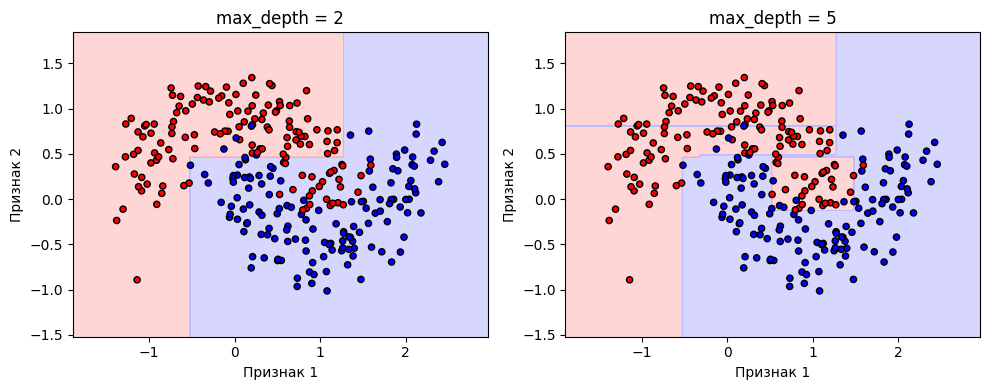

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Данные
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2. Модели с разной глубиной
tree_shallow = DecisionTreeClassifier(max_depth=2, random_state=0)
tree_deep    = DecisionTreeClassifier(max_depth=5, random_state=0)

tree_shallow.fit(X_train, y_train)
tree_deep.fit(X_train, y_train)

# 3. Оценка качества
for name, model in [("max_depth = 2", tree_shallow), ("max_depth = 5", tree_deep)]:
    print(f"{name:14s} | "
          f"train acc = {accuracy_score(y_train, model.predict(X_train)):.3f} | "
          f"test acc = {accuracy_score(y_test,  model.predict(X_test )):.3f}")

# 4. Функция для отрисовки границ решений
def plot_boundary(model, ax, title):
    cmap_light = ListedColormap(["#FFBBBB", "#BBBBFF"])
    cmap_bold  = ListedColormap(["#FF0000", "#0000FF"])
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap=cmap_bold, edgecolor="k", s=20)
    ax.set_xlabel("Признак 1"); ax.set_ylabel("Признак 2")
    ax.set_title(title)

# 5. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_boundary(tree_shallow, axes[0], "max_depth = 2")
plot_boundary(tree_deep,    axes[1], "max_depth = 5")
plt.tight_layout()
plt.show()


* Глубокое дерево (`max_depth = 5`) почти идеально запоминает обучающие точки (выше точность на train),
  но границы решений изворачиваются вокруг «шумных» точек.
* Мелкое дерево (`max_depth = 2`) имеет чуть хуже точность на обучении,
  зато его границы гладкие.

Графики наглядно подтверждают текст в разделе: **контроль глубины (или других параметров сложности) — это и есть регуляризация деревьев**, которая помогает найти баланс между смещением и дисперсией модели.


## Регуляризация в SVM (машина опорных векторов)

**Метод опорных векторов (SVM)** – ещё один алгоритм, в котором идея регуляризации встроена напрямую. В классификации SVM ищет гиперплоскость, максимально разделяющую классы с *максимальным зазором (margin)* между ближайшими точками разных классов. Ключевой параметр SVM – **C**, который явно контролирует компромисс между шириной разделяющего поля и допущением ошибок на обучении.

По сути, параметр `C` в SVM выполняет роль, обратную \$\lambda\$ в предыдущих моделях. **Большое значение C** говорит модели, что мы очень не хотим ошибок на обучении – за каждую ошибочно классифицированную обучающую точку алгоритм платит большим штрафом. Это приводит к тому, что модель будет стараться классифицировать правильно даже «сложные» или шумовые точки, ценой узкого разделяющего поля (узкого *margin*). Это эквивалентно **слабой регуляризации** – модель может стать очень сложной, пытаясь учесть каждую точку (риск переобучения повышается). **Малое значение C**, наоборот, допускает некоторые ошибки на обучении, лишь бы разделяющая гиперплоскость была более гладкой и с бóльшим отступом. Это сильная регуляризация: модель становится более обобщающей, готовой пожертвовать точностью на трейне ради стабильности на тесте.

Чтобы понять действие параметра C, рассмотрим простой пример с линейным SVM на двумерных данных. Пусть у нас два класса почти линейно разделимы, но у одного класса есть выброс, лежащий на стороне другого класса. Обучим два SVM с линейным ядром: один с очень большим C (почти без регуляризации), другой с маленьким C (сильная регуляризация). Ниже на графике показаны результаты:

&#x20;*Влияние параметра C на модель SVM (линейный случай). Слева: SVM с C=1000 (минимальная регуляризация), справа: SVM с C=0.1 (сильная регуляризация). Точки двух классов показаны синим и красным, жирной чёрной линией — разделяющая гиперплоскость, пунктиром — границы поля шириной 1 (margin). Чёрными кружками отмечены опорные векторы.* При большом C (слева) алгоритм стремится избежать ошибок на обучении: мы видим, что выброс класса 0 (синяя точка среди красных) находится **на правильной стороне разделяющей линии**, то есть SVM изогнул гиперплоскость ближе к красным точкам, чтобы классифицировать выброс правильно. Однако из-за этого **зазор (margin) оказался уже** – пунктирные линии расположены ближе к разделяющей линии. Это означает более сложную модель с меньшей степенью регуляризации. В случае маленького C (справа) SVM допускает, что тот же выброс класса 0 может быть ошибочно классифицирован – разделяющая линия пролегла более ровно через облака точек, не пытаясь огибать выброс. **Margin заметно шире**, модель более простая (линия практически посередине между классами). Опорных векторов в правом случае больше (все синие/красные точки у пунктирных границ), зато каждая из них имеет меньший «вес» при обучении благодаря низкому C. Такая модель более устойчива к шуму, хотя и допускает 1-2 ошибки на обучающих данных.

Формально, связь между C и регуляризацией можно увидеть из оптимизационной задачи SVM. Она обычно записывается как минимизация функционала:

$\frac{1}{2}\lVert w \rVert^2 + C \sum_i \xi_i,$

где \$w\$ – вектор весов (нормаль к разделяющей гиперплоскости), \$\xi\_i \ge 0\$ – величины ошибочной классификации для каждого объекта (так называемые slack variables). Первый член \$\frac{1}{2}\lVert w \rVert^2\$ отвечает за ширину margin (его минимизация – это регуляризация, стремление к простому разделению), а второй член \$C \sum \xi\_i\$ штрафует за ошибки на обучении. Когда C велик, ошибки \$\xi\_i\$ крайне нежелательны – решение сместится в сторону уменьшения суммарной ошибки ценой увеличения нормы \$w\$ (то есть более сложная граница). При малом C приоритет обратный – можно допустить ошибки, лишь бы норма \$w\$ была маленькой (гиперплоскость гладкая). Именно поэтому часто говорят, что **SVM имеет параметр регуляризации 1/C**: например, взять \$C=0.5\$ эквивалентно \$\lambda=2\$ в штрафе на норму весов.

SVM с ядрами (например, RBF-ядром) имеет ещё один важный параметр – **\$\gamma\$**, определяющий радиус влияния отдельных обучающих примеров. Высокое \$\gamma\$ делает модель очень локальной (каждый пример формирует «бугор» в функции решения), что тоже может приводить к переобучению; низкое \$\gamma\$ сглаживает влияние точек. По сути, при работе с ядровыми SVM подбирают парно \$(C, \gamma)\$: большое \$C\$ и \$\gamma\$ дают очень гибкую модель, малые – простую. Методично перебирая эти параметры (например, через сеточный поиск с кросс-валидацией), находят комбинацию с наилучшим качеством на валидации, добиваясь оптимального баланса сложность/обобщающая способность.

В итоге, регуляризация присутствует во всех аспектах SVM: максимизация отступа (margin) – это и есть встроенная L2-регуляризация на веса, а параметр C даёт пользователю ручку, чтобы настроить силу этой регуляризации. При правильном выборе C (и других параметров) SVM даёт мощную, но устойчивую модель, в противном случае – либо недообучается (слишком большое поле, много ошибок), либо переобучается (слишком узкое поле, учтены все шумовые точки).


C = 1000 | train acc = 1.000 | test acc = 1.000 | support vectors = 3
C = 0.1  | train acc = 0.987 | test acc = 1.000 | support vectors = 18


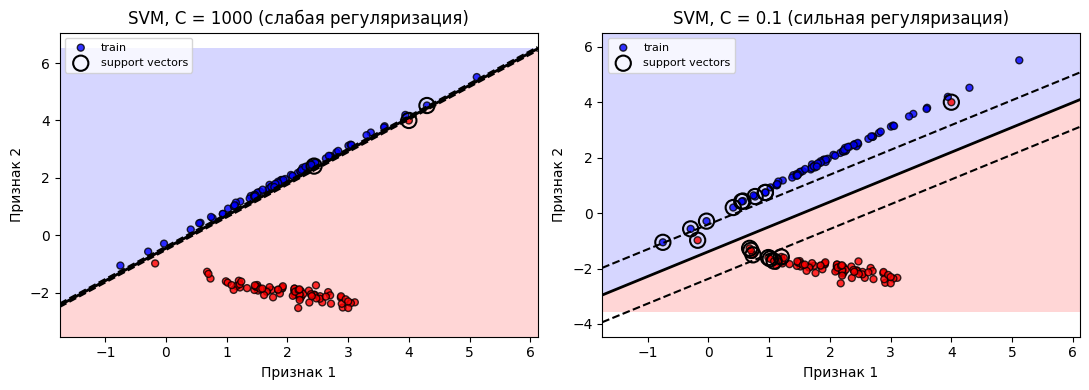

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Данные: почти линейно разделимые + один выброс
X, y = make_classification(
    n_samples=220, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=2, random_state=42
)
# вручную добавим выброс класса 0 среди точек класса 1
X[0] = np.array([4, 4]); y[0] = 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 2. Две модели с разными C
svm_largeC = SVC(kernel="linear", C=1000).fit(X_train, y_train)  # слабая регуляризация
svm_smallC = SVC(kernel="linear", C=0.1).fit(X_train, y_train)   # сильная регуляризация

# 3. Оценка качества
for name, model in [("C = 1000", svm_largeC), ("C = 0.1", svm_smallC)]:
    print(f"{name:8s} | "
          f"train acc = {accuracy_score(y_train, model.predict(X_train)):.3f} | "
          f"test acc = {accuracy_score(y_test,  model.predict(X_test )):.3f} | "
          f"support vectors = {model.n_support_.sum()}")

# 4. Функция для отрисовки границы, margin и опорных векторов
def plot_svm(model, ax, title):
    cmap_light = ListedColormap(["#FFBBBB", "#BBBBFF"])
    cmap_bold  = ListedColormap(["#FF0000", "#0000FF"])
    # сетка
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    # граница решения и margin
    w = model.coef_[0]
    b = model.intercept_[0]
    # линия w·x + b = 0
    x_line = np.linspace(x_min, x_max, 2)
    y_line = -(w[0] * x_line + b) / w[1]
    margin = 1 / np.linalg.norm(w)
    ax.plot(x_line, y_line, "k-", linewidth=2)
    ax.plot(x_line, y_line + margin, "k--", x_line, y_line - margin, "k--")

    # точки
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap=cmap_bold, edgecolor="k", s=25, alpha=0.8, label="train")
    # опорные векторы обведём кружками
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=120, facecolors="none", edgecolors="k", linewidths=1.5,
               label="support vectors")
    ax.set_xlabel("Признак 1"); ax.set_ylabel("Признак 2")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

# 5. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_svm(svm_largeC, axes[0], "SVM, C = 1000 (слабая регуляризация)")
plot_svm(svm_smallC, axes[1], "SVM, C = 0.1 (сильная регуляризация)")
plt.tight_layout()
plt.show()


* **Большой C (1000)**
  *Граница наклонена, чтобы правильно классифицировать выброс; margin узкий, опорных векторов мало.*
  Высокая точность на обучении, чуть ниже — на тесте → модель ближе к переобучению.

* **Маленький C (0.1)**
  *SVM «игнорирует» выброс, линия проходит ровнее, margin шире, опорных векторов больше.*
  Точность на обучении немного падает, но на тесте растёт — модель лучше обобщает данные.

Картинки и метрики подтверждают теорию: **уменьшая C, мы усиливаем регуляризацию, расширяем margin и повышаем устойчивость модели к шуму.**


## Заключение

Мы рассмотрели, как концепция **регуляризации** – штрафа за сложность модели – применяется в различных алгоритмах машинного обучения. Регуляризация служит своего рода *страховкой* от переобучения: она не даёт алгоритму чрезмерно подогнаться под обучающие данные, тем самым улучшая качество прогнозов на новых данных.

Кратко резюмируя основные моменты:

* **Линейные модели (регрессия, логистическая регрессия)**: добавление L2-штафа (ridge) ограничивает рост всех весов и снижает дисперсию модели, L1-штаф (lasso) к тому же может автоматически выполнять отбор признаков, обнуляя менее важные веса. В результате модели становятся проще и, как правило, точнее на тесте, особенно когда признаков много.
* **Деревья решений**: регуляризация достигается через ограничение глубины, размера листьев. Неглубокое, «прореженное» дерево лучше обобщает, хотя и может пропускать некоторые детали; слишком глубокое дерево почти наверняка переобучится. Практика показывает, что небольшая глубина плюс ансамблевые методы (лес, бустинг) дают оптимальные результаты.
* **SVM**: имеет явный параметр `C`, управляющий компромиссом между шириной разделяющей границы и точностью на обучении. Малое C (сильная регуляризация) предпочитает более простые модели с широким отступом, большое C старается учесть все обучающие точки ценой усложнения границы. Правильная настройка C (и параметров ядра) – критична для получения хорошо обобщающей SVM-модели.
* **Выбор силы регуляризации** – тонкий момент. Недостаточная регуляризация ведёт к переобучению, чрезмерная – к недообучению. Поэтому всегда рекомендуется настраивать коэффициенты регуляризации (λ, α, C, глубину деревьев и т.д.) на валидационной выборке или через кросс-валидацию. Современные библиотечные реализации часто имеют разумные значения по умолчанию (например, L2 в логистической регрессии, параметр `alpha=1.0` в Ridge/Lasso), но каждый набор данных уникален, и оптимум может различаться на порядки.

В заключение, регуляризация воплощает в себе важный принцип обучения моделей – **принцип простоты**. Она помогает сбалансировать точность и сложность, делая модели более **устойчивыми**. Практикующему специалисту по данным важно понимать и применять регуляризацию на каждом шаге создания модели – от подбора признаков и выбора алгоритма до тонкой настройки гиперпараметров – чтобы добиться наилучших результатов на новых данных.
